# set up

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [5]:
from sklearn.linear_model import LinearRegression

In [6]:
from sklearn.neighbors import KNeighborsRegressor

In [61]:
from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from sklearn.svm import SVR

In [1]:
!pip install qiskit qiskit-machine-learning -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.8 MB/s eta 0:00:00


In [54]:
from sklearn.preprocessing import MinMaxScaler

# start

In [7]:
file_path = "/content/20260501_20260531_Amity_Univ_Raipur.lev15"

In [8]:
df = pd.read_csv(file_path, skiprows=6)

In [9]:
df.head()

,Date(dd:mm:yyyy),Time(hh:mm:ss),Day_of_Year,Day_of_Year(Fraction),AOD_1640nm,AOD_1020nm,AOD_870nm,AOD_865nm,AOD_779nm,AOD_675nm,...,Exact_Wavelengths_of_AOD(um)_380nm,Exact_Wavelengths_of_AOD(um)_340nm,Exact_Wavelengths_of_PW(um)_935nm,Exact_Wavelengths_of_AOD(um)_681nm,Exact_Wavelengths_of_AOD(um)_709nm,Exact_Wavelengths_of_AOD(um)_Empty,Exact_Wavelengths_of_AOD(um)_Empty.1,Exact_Wavelengths_of_AOD(um)_Empty.2,Exact_Wavelengths_of_AOD(um)_Empty.3,Exact_Wavelengths_of_AOD(um)_Empty.4
0,01:05:2026,00:49:23,121,121.034294,0.325153,0.402562,0.425830,-999.0,-999.0,0.479577,...,0.3797,-999.0000,0.937,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
1,01:05:2026,00:57:54,121,121.040208,0.295219,0.370371,0.396432,-999.0,-999.0,0.452559,...,0.3797,0.3397,0.937,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
2,01:05:2026,01:00:13,121,121.041817,0.294355,0.368201,0.392333,-999.0,-999.0,0.444467,...,0.3797,0.3397,0.937,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
3,01:05:2026,01:03:36,121,121.044167,0.283013,0.354040,0.377410,-999.0,-999.0,0.426598,...,0.3797,0.3397,0.937,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
4,01:05:2026,01:10:13,121,121.048762,0.282878,0.352955,0.376758,-999.0,-999.0,0.424978,...,0.3797,0.3397,0.937,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0


In [10]:
df.columns

Index(['Date(dd:mm:yyyy)', 'Time(hh:mm:ss)', 'Day_of_Year',
       'Day_of_Year(Fraction)', 'AOD_1640nm', 'AOD_1020nm', 'AOD_870nm',
       'AOD_865nm', 'AOD_779nm', 'AOD_675nm',
       ...
       'Exact_Wavelengths_of_AOD(um)_380nm',
       'Exact_Wavelengths_of_AOD(um)_340nm',
       'Exact_Wavelengths_of_PW(um)_935nm',
       'Exact_Wavelengths_of_AOD(um)_681nm',
       'Exact_Wavelengths_of_AOD(um)_709nm',
       'Exact_Wavelengths_of_AOD(um)_Empty',
       'Exact_Wavelengths_of_AOD(um)_Empty.1',
       'Exact_Wavelengths_of_AOD(um)_Empty.2',
       'Exact_Wavelengths_of_AOD(um)_Empty.3',
       'Exact_Wavelengths_of_AOD(um)_Empty.4'],
      dtype='object', length=113)

In [11]:
df['Date'] = pd.to_datetime(df['Date(dd:mm:yyyy)'],format='%d:%m:%Y')

In [12]:
df.set_index('Date', inplace=True)

In [13]:
df.head()

,Date(dd:mm:yyyy),Time(hh:mm:ss),Day_of_Year,Day_of_Year(Fraction),AOD_1640nm,AOD_1020nm,AOD_870nm,AOD_865nm,AOD_779nm,AOD_675nm,...,Exact_Wavelengths_of_AOD(um)_380nm,Exact_Wavelengths_of_AOD(um)_340nm,Exact_Wavelengths_of_PW(um)_935nm,Exact_Wavelengths_of_AOD(um)_681nm,Exact_Wavelengths_of_AOD(um)_709nm,Exact_Wavelengths_of_AOD(um)_Empty,Exact_Wavelengths_of_AOD(um)_Empty.1,Exact_Wavelengths_of_AOD(um)_Empty.2,Exact_Wavelengths_of_AOD(um)_Empty.3,Exact_Wavelengths_of_AOD(um)_Empty.4
Date,,,,,,,,,,,,,,,,,,,,,
2026-05-01,01:05:2026,00:49:23,121,121.034294,0.325153,0.402562,0.425830,-999.0,-999.0,0.479577,...,0.3797,-999.0000,0.937,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
2026-05-01,01:05:2026,00:57:54,121,121.040208,0.295219,0.370371,0.396432,-999.0,-999.0,0.452559,...,0.3797,0.3397,0.937,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
2026-05-01,01:05:2026,01:00:13,121,121.041817,0.294355,0.368201,0.392333,-999.0,-999.0,0.444467,...,0.3797,0.3397,0.937,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
2026-05-01,01:05:2026,01:03:36,121,121.044167,0.283013,0.354040,0.377410,-999.0,-999.0,0.426598,...,0.3797,0.3397,0.937,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
2026-05-01,01:05:2026,01:10:13,121,121.048762,0.282878,0.352955,0.376758,-999.0,-999.0,0.424978,...,0.3797,0.3397,0.937,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0


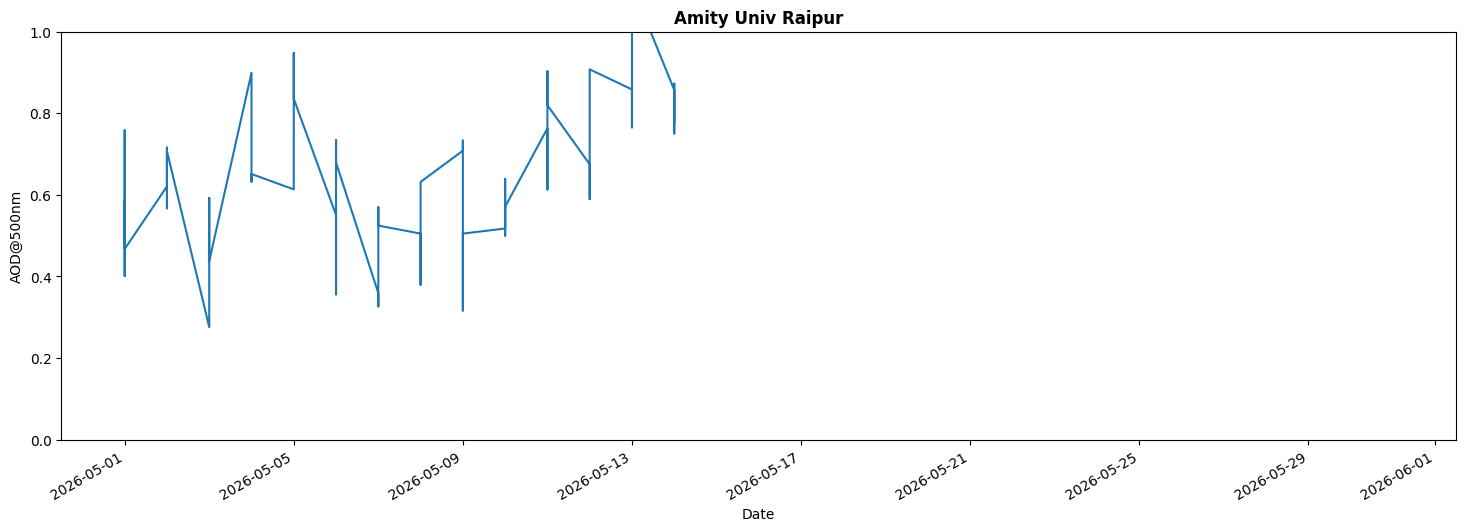

In [14]:
fig = plt.figure(figsize=(18,6))
df['AOD_500nm'].plot(ylim=(0,1))
df['AOD_500nm'].resample('1ME').mean().plot(ylim=(0,1),lw=3)
plt.title('Amity Univ Raipur', weight='bold')
plt.ylabel('AOD@500nm')
plt.show()

In [15]:
df.replace(-999, np.nan, inplace=True)

In [16]:
df.columns

Index(['Date(dd:mm:yyyy)', 'Time(hh:mm:ss)', 'Day_of_Year',
       'Day_of_Year(Fraction)', 'AOD_1640nm', 'AOD_1020nm', 'AOD_870nm',
       'AOD_865nm', 'AOD_779nm', 'AOD_675nm',
       ...
       'Exact_Wavelengths_of_AOD(um)_380nm',
       'Exact_Wavelengths_of_AOD(um)_340nm',
       'Exact_Wavelengths_of_PW(um)_935nm',
       'Exact_Wavelengths_of_AOD(um)_681nm',
       'Exact_Wavelengths_of_AOD(um)_709nm',
       'Exact_Wavelengths_of_AOD(um)_Empty',
       'Exact_Wavelengths_of_AOD(um)_Empty.1',
       'Exact_Wavelengths_of_AOD(um)_Empty.2',
       'Exact_Wavelengths_of_AOD(um)_Empty.3',
       'Exact_Wavelengths_of_AOD(um)_Empty.4'],
      dtype='object', length=113)

In [17]:
cols = [
    "AOD_500nm",
    "Precipitable_Water(cm)",
    "440-870_Angstrom_Exponent",
    "Solar_Zenith_Angle(Degrees)"
    ]

In [18]:
df_new = df[cols]

In [19]:
df_new.head()

,AOD_500nm,Precipitable_Water(cm),440-870_Angstrom_Exponent,Solar_Zenith_Angle(Degrees)
Date,,,,
2026-05-01,0.585835,2.994726,0.617418,80.002395
2026-05-01,0.560400,3.027478,0.662041,78.076525
2026-05-01,0.545361,3.000079,0.635049,77.551111
2026-05-01,0.522821,2.992571,0.627916,76.782737
2026-05-01,0.518017,2.973203,0.610703,75.276799


In [20]:
df.dropna(inplace=True)

In [21]:
df_sam = df_new.head(100)

In [22]:
df_sam.shape

(100, 4)

In [23]:
df_new.shape

(852, 4)

In [24]:
X = df_sam.drop(columns=["AOD_500nm"])
y = df_sam["AOD_500nm"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
print(len(X_train))
print(len(X_test))

80
20


In [27]:
rf = RandomForestRegressor(n_estimators=50,random_state=42)

In [28]:
rf.fit(X_train,y_train)

RandomForestRegressor(n_estimators=50, random_state=42)

In [29]:
y_pred = rf.predict(X_test)

In [30]:
y_pred

array([0.58950202, 0.54054174, 0.48048656, 0.57289158, 0.59257554,
       0.65622472, 0.56131404, 0.58874254, 0.51338776, 0.53900092,
       0.53619922, 0.5676716 , 0.5280031 , 0.71964974, 0.61532578,
       0.5250129 , 0.59679016, 0.5905779 , 0.5091518 , 0.69024464])

In [31]:
df_com = pd.DataFrame({"actual"  : y_test.values, "predicted" : y_pred})

In [32]:
df_com.head()

,actual,predicted
0,0.589859,0.589502
1,0.526175,0.540542
2,0.620327,0.480487
3,0.596113,0.572892
4,0.601934,0.592576


In [33]:
mae_rf = mean_absolute_error(y_test, y_pred)

In [34]:
mae_rf

0.024259803000000003

In [35]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred))

In [36]:
rmse_rf

np.float64(0.04057400822033412)

In [37]:
lr = LinearRegression()

In [38]:
lr.fit(X_train, y_train)

LinearRegression()

In [39]:
y_pred_lr = lr.predict(X_test)

In [40]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

In [41]:
mae_lr

0.0428905557667908

In [42]:
rmse_lr

np.float64(0.05331293896215516)

In [43]:
knn = KNeighborsRegressor(n_neighbors=3)

In [44]:
knn.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=3)

In [45]:
y_pred_knn = knn.predict(X_test)

In [46]:
mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))

In [47]:
mae_knn

0.03797261666666665

In [48]:
rmse_knn

np.float64(0.04635657240702528)

In [49]:
results = pd.DataFrame({
    "Model": ["Linear Regression","KNN Regressor","Random Forest"],
    "MAE": [mae_lr,mae_knn,mae_rf],
    "RMSE": [rmse_lr,rmse_knn,rmse_rf]})

In [50]:
results

,Model,MAE,RMSE
0,Linear Regression,0.042891,0.053313
1,KNN Regressor,0.037973,0.046357
2,Random Forest,0.024260,0.040574


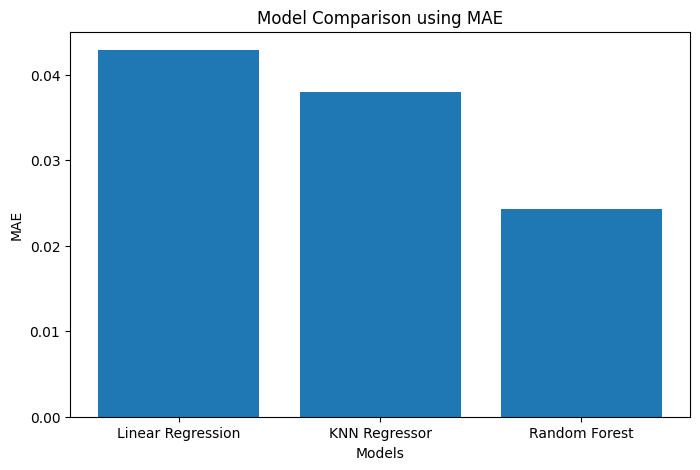

In [51]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["MAE"])
plt.xlabel("Models")
plt.ylabel("MAE")
plt.title("Model Comparison using MAE")
plt.show()

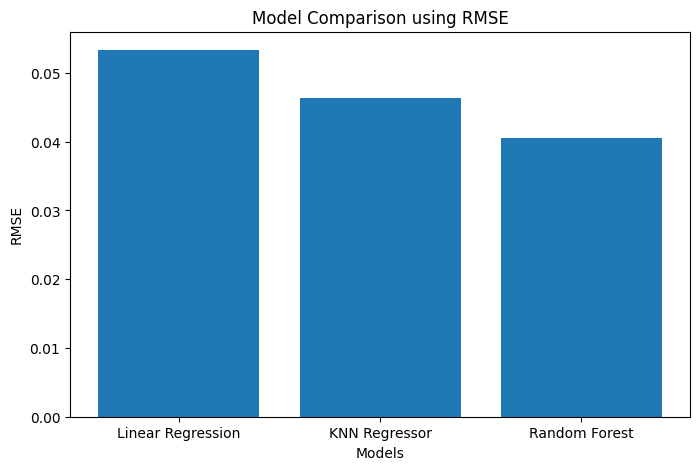

In [52]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["RMSE"])
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("Model Comparison using RMSE")
plt.show()

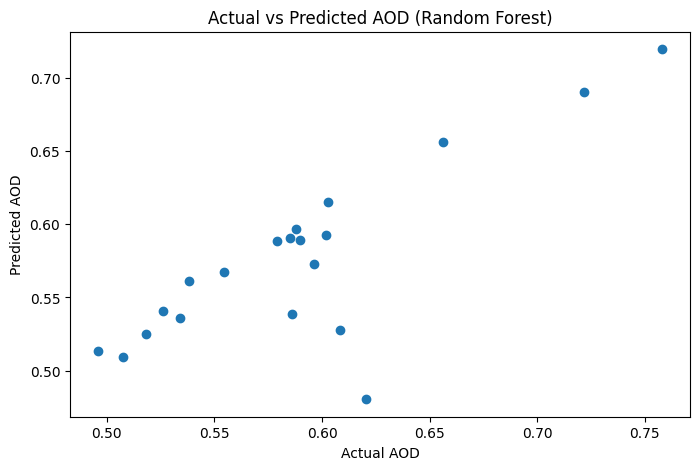

In [53]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual AOD")
plt.ylabel("Predicted AOD")
plt.title("Actual vs Predicted AOD (Random Forest)")
plt.show()

# QISKIT

In [55]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(X_scaled,y,test_size=0.2,random_state=42)

In [56]:
X_train_q = X_train_q[:40]
X_test_q = X_test_q[:10]
y_train_q = y_train_q[:40]
y_test_q = y_test_q[:10]

In [62]:
feature_map = zz_feature_map(feature_dimension=X_train_q.shape[1],reps=2)

In [65]:
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

In [66]:
kernel_train = quantum_kernel.evaluate(x_vec=X_train_q)

In [67]:
kernel_test = quantum_kernel.evaluate(x_vec=X_test_q,y_vec=X_train_q)

In [68]:
qsvr = SVR(kernel="precomputed")

In [69]:
qsvr.fit(kernel_train, y_train_q)


SVR(kernel='precomputed')

In [70]:
y_pred_q = qsvr.predict(kernel_test)

In [71]:
print(y_pred_q[:5])

[0.56070705 0.56346274 0.57910188 0.58634711 0.5892469 ]


In [72]:
mae_q = mean_absolute_error(y_test_q, y_pred_q)
rmse_q = np.sqrt(mean_squared_error(y_test_q, y_pred_q))

In [73]:
mae_q

0.029747999985917324

In [74]:
rmse_q

np.float64(0.03321042738040647)

In [75]:
results.loc[len(results)] = ["Quantum Kernel SVR",mae_q,rmse_q]

In [76]:
print(results)

                Model       MAE      RMSE
0   Linear Regression  0.042891  0.053313
1       KNN Regressor  0.037973  0.046357
2       Random Forest  0.024260  0.040574
3  Quantum Kernel SVR  0.029748  0.033210


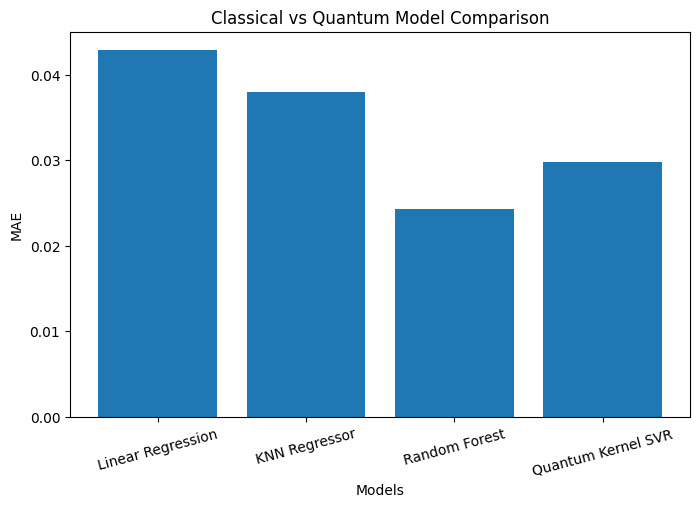

In [77]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["MAE"])
plt.xlabel("Models")
plt.ylabel("MAE")
plt.title("Classical vs Quantum Model Comparison")
plt.xticks(rotation=15)
plt.show()